In [ ]:
import pandas as pd
import glob

In [ ]:
# grab all daily files and combine
files = glob.glob("POWER_*.csv")

dfs = [pd.read_csv(f) for f in files]
wide = pd.concat(dfs, ignore_index=True)

In [ ]:
# pivot wide -> long
id_cols = ["entity_id", "type", "unit"]
long = wide.melt(id_vars=id_cols, var_name="timestamp", value_name="power_w")
long = long.dropna(subset=["power_w"])

long["power_w"] = pd.to_numeric(long["power_w"])
long["timestamp"] = pd.to_datetime(long["timestamp"], format="mixed", utc=True)

# clean duplicates
long = long.drop_duplicates(subset=["entity_id", "timestamp"])

# sort by time 
long = long.sort_values(by=['timestamp'])

# categorise as weekday / weekend
long['day_type'] = long['timestamp'].dt.dayofweek.apply(lambda x: 'Weekend' if x >= 5 else 'Weekday')
long = long[['timestamp', 'power_w', 'day_type']]


In [ ]:
long.head(10)

,timestamp,power_w,day_type
758374,2026-07-11 20:12:22.524808+00:00,2.750,Weekend
758396,2026-07-11 20:12:52.717167+00:00,2.667,Weekend
758418,2026-07-11 20:13:22.538735+00:00,2.878,Weekend
758440,2026-07-11 20:13:52.523467+00:00,2.975,Weekend
758462,2026-07-11 20:14:22.651051+00:00,2.928,Weekend
758484,2026-07-11 20:14:52.526337+00:00,2.987,Weekend
758506,2026-07-11 20:15:22.533235+00:00,2.969,Weekend
758528,2026-07-11 20:15:52.515931+00:00,3.257,Weekend
758550,2026-07-11 20:16:22.516593+00:00,2.889,Weekend
758572,2026-07-11 20:16:52.653037+00:00,3.003,Weekend


Unsupervised ensemble pipeline - For Operating Mode Detection (idle/used)

methodology:
https://www.sciencedirect.com/science/article/pii/S0306261924004811#sec3

1. data pre-processing 
- filter 0W, missing data (NaN) and extreme positive outliers removed prior to clustering 
- input: raw W readings 

2. runs 5 independent sub-classifers simultaneously, each assigning a binary prediction (1 for active, 0 for unused / idle)
- Model 1 & 2 (Statistical Thresholding): Simple, fast heuristic rules based on statistical metrics (e.g., historical median and 70th-percentile power thresholds).
- Model 3 (K-Means Clustering): Partitioning the power trace data into K=2 clusters using k-means++ initialization and Euclidean distance metrics.  
- Model 4 (Global Gaussian Mixture Model - GMM): Fitting a 2-component GMM across the device's entire historical power trace to capture multimodal energy distributions.
- Model 5 (Sliding-Window GMM): Fitting a GMM over a rolling temporal window (recent local history) to adapt dynamically to power drift or behavioral changes over time.

3. Voting-based consensus filter 
time step is classified as Active if a majority of the models agree.
confidence score


In [ ]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture

# unsupervised algs to separate 'lower power / idle' from 'high power / active'

class PlugLoadModeDetector30s:
    def __init__(self, recent_window_days: int = 5, sampling_freq_seconds: int = 30):
        """
        Unsupervised ensemble pipeline adapted for high-frequency short-duration traces.
        
        Parameters:
        - recent_window_days: Days of recent data for Model 5 (Local GMM). Default: 5 days.
        - sampling_freq_seconds: Time-series resolution in seconds. Default: 30s.
        """
        self.recent_window_days = recent_window_days
        self.points_per_day = int((24 * 3600) / sampling_freq_seconds)  # 2,880 for 30s
        self.window_size = self.recent_window_days * self.points_per_day

    def _preprocess_data(self, series: pd.Series) -> pd.Series:
        """Removes extreme outliers (> mean + 30*std if count < 5)."""
        data = series.copy()
        valid_data = data.dropna()
        valid_data = valid_data[valid_data > 0]
        
        if len(valid_data) > 0:
            mean_val = valid_data.mean()
            std_val = valid_data.std()
            cutoff = mean_val + 30 * std_val
            outliers = valid_data[valid_data > cutoff]
            
            # Remove up to 4 extreme outlier readings
            if 0 < len(outliers) < 5:
                data.loc[outliers.index] = np.nan
                
        return data

    def _post_process_labels(self, data: pd.Series, labels: np.ndarray, model_type: str = 'clustering') -> np.ndarray:
        """Applies label alignment, zero-power override, and median boundary corrections."""
        df = pd.DataFrame({'power': data, 'label': labels})
        
        # 1. Label Mapping: Ensure Cluster 0 corresponds to lower average power
        mean_0 = df[df['label'] == 0]['power'].mean()
        mean_1 = df[df['label'] == 1]['power'].mean()
        if mean_0 > mean_1:
            df['label'] = 1 - df['label']

        # 2. Hard zero override: 0 W is always unused (0)
        df.loc[df['power'] == 0, 'label'] = 0

        # 3. Median boundary cleanup (primarily for GMM boundary edge cases)
        if model_type == 'gmm':
            cluster_0_power = df[df['label'] == 0]['power'].dropna()
            cluster_1_power = df[df['label'] == 1]['power'].dropna()
            
            if not cluster_0_power.empty and not cluster_1_power.empty:
                med_0 = cluster_0_power.median()
                med_1 = cluster_1_power.median()
                
                # Reclassify boundary misallocations
                df.loc[(df['power'] < med_0) & (df['label'] == 1), 'label'] = 0
                df.loc[(df['power'] > med_1) & (df['label'] == 0), 'label'] = 1

        return df['label'].values

    def fit_predict(self, power_series: pd.Series) -> pd.DataFrame:
        """
        Runs the 5-model ensemble on input power data.
        Returns DataFrame with individual model votes and final consensus decision.
        """
        cleaned_series = self._preprocess_data(power_series)
        
        # Extract valid non-zero, non-NaN indices for clustering training
        valid_mask = cleaned_series.notna() & (cleaned_series > 0)
        valid_indices = cleaned_series[valid_mask].index
        train_data = cleaned_series.loc[valid_indices].values.reshape(-1, 1)

        predictions = pd.DataFrame(index=power_series.index)
        predictions['raw_power'] = power_series

        # -------------------------------------------------------------
        # Model 1: Median Threshold
        # -------------------------------------------------------------
        med_threshold = power_series.dropna().median()
        predictions['m1_median'] = (power_series > med_threshold).astype(int)

        # -------------------------------------------------------------
        # Model 2: 70th Percentile Threshold
        # -------------------------------------------------------------
        p70_threshold = np.nanpercentile(power_series.dropna().values, 70)
        predictions['m2_percentile70'] = (power_series > p70_threshold).astype(int)

        # -------------------------------------------------------------
        # Model 3: Global K-Means (K=2)
        # -------------------------------------------------------------
        kmeans = KMeans(n_clusters=2, init='k-means++', random_state=42, n_init=10)
        km_labels_valid = kmeans.fit_predict(train_data)
        
        m3_full = np.zeros(len(power_series), dtype=int)
        m3_full[power_series.index.get_indexer(valid_indices)] = km_labels_valid
        predictions['m3_kmeans'] = self._post_process_labels(power_series, m3_full, 'clustering')

        # -------------------------------------------------------------
        # Model 4: Global GMM (K=2) across all 20 days
        # -------------------------------------------------------------
        gmm_global = GaussianMixture(n_components=2, init_params='kmeans', random_state=42)
        gmm_global_labels_valid = gmm_global.fit_predict(train_data)
        
        m4_full = np.zeros(len(power_series), dtype=int)
        m4_full[power_series.index.get_indexer(valid_indices)] = gmm_global_labels_valid
        predictions['m4_gmm_global'] = self._post_process_labels(power_series, m4_full, 'gmm')

        # -------------------------------------------------------------
        # Model 5: Local GMM (Most Recent 5 Days = 14,400 samples)
        # -------------------------------------------------------------
        recent_data = train_data[-self.window_size:] if len(train_data) >= self.window_size else train_data
        
        gmm_local = GaussianMixture(n_components=2, init_params='kmeans', random_state=42)
        gmm_local.fit(recent_data)
        gmm_local_labels_valid = gmm_local.predict(train_data)
        
        m5_full = np.zeros(len(power_series), dtype=int)
        m5_full[power_series.index.get_indexer(valid_indices)] = gmm_local_labels_valid
        predictions['m5_gmm_local'] = self._post_process_labels(power_series, m5_full, 'gmm')

        # -------------------------------------------------------------
        # Consensus Voting: >= 4 models vote active (1) -> Active (1)
        # -------------------------------------------------------------
        model_cols = ['m1_median', 'm2_percentile70', 'm3_kmeans', 'm4_gmm_global', 'm5_gmm_local']
        predictions['active_votes'] = predictions[model_cols].sum(axis=1)
        predictions['final_ensemble'] = (predictions['active_votes'] >= 4).astype(int)

        return predictions

In [ ]:
detector = PlugLoadModeDetector30s(recent_window_days=5, sampling_freq_seconds=30)
power = long["power_w"]

# 5. Run the 5-model ensemble detector on your data
results = detector.fit_predict(power)

# Merge the ensemble outputs back onto the original dataframe by index
long = long.join(results[['active_votes', 'final_ensemble']])

# Keep only the columns you want
long = long[['timestamp', 'power_w', 'day_type', 'active_votes', 'final_ensemble']]

long.to_csv('power_classification_results.csv', index=False)

print("Classification complete!")

Classification complete!


In [ ]:
long.head(15)

,timestamp,power_w,day_type,active_votes,final_ensemble
758374,2026-07-11 20:12:22.524808+00:00,2.750,Weekend,0,0
758396,2026-07-11 20:12:52.717167+00:00,2.667,Weekend,0,0
758418,2026-07-11 20:13:22.538735+00:00,2.878,Weekend,0,0
758440,2026-07-11 20:13:52.523467+00:00,2.975,Weekend,1,0
758462,2026-07-11 20:14:22.651051+00:00,2.928,Weekend,0,0
758484,2026-07-11 20:14:52.526337+00:00,2.987,Weekend,1,0
758506,2026-07-11 20:15:22.533235+00:00,2.969,Weekend,1,0
758528,2026-07-11 20:15:52.515931+00:00,3.257,Weekend,2,0
758550,2026-07-11 20:16:22.516593+00:00,2.889,Weekend,0,0
758572,2026-07-11 20:16:52.653037+00:00,3.003,Weekend,1,0


In [ ]:
print(long['final_ensemble'].value_counts())
print(long['active_votes'].value_counts().sort_index())

final_ensemble
0    50619
1     7759
Name: count, dtype: int64
active_votes
0    29279
1    11629
2     9704
3        7
4     5909
5     1850
Name: count, dtype: int64


In [ ]:
long[long['final_ensemble'] == 1]

,timestamp,power_w,day_type,active_votes,final_ensemble
758858,2026-07-11 20:23:22.520747+00:00,665.456,Weekend,4,1
759188,2026-07-11 20:30:52.509769+00:00,1576.548,Weekend,5,1
759518,2026-07-11 20:38:22.530004+00:00,2004.601,Weekend,5,1
759628,2026-07-11 20:40:52.529402+00:00,1665.388,Weekend,5,1
760200,2026-07-11 20:53:52.524045+00:00,1884.151,Weekend,5,1
...,...,...,...,...,...
831129,2026-08-01 23:49:06.499998+00:00,816.483,Weekend,4,1
831239,2026-08-01 23:51:36.506754+00:00,1727.020,Weekend,5,1
831349,2026-08-01 23:54:06.504802+00:00,2005.491,Weekend,5,1
831459,2026-08-01 23:56:36.502277+00:00,1732.908,Weekend,5,1


In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.colors import LinearSegmentedColormap

# setup colours / cmap 

color_dict = {'Tawny': '#CE5C22',
              'Dark orange': '#FF973D',
              'Timberwolf': '#D9D7CD',
              'Space cadet': '#2F2D4D',
              'Dark spring green': '#337357',
              'Asparagus': '#6D9F71',
              'Olivine': '#B5CA8D'}

base_colors = ['#D9D7CD', '#B5CA8D', '#6D9F71', '#337357', '#2F2D4D']
basic_cmap = LinearSegmentedColormap.from_list("custom_palette", base_colors)
num_colors = 100
custom_cmap = [basic_cmap(i / num_colors) for i in range(num_colors)]


# aggegation 

def custom_agg_downsampling(values):
    values_array = np.array(values, dtype=float)
    if all(np.isnan(values_array)):
        return np.nan
    return np.nanmean(values_array)


# heatmap function (unchanged)

def plot_weekly_heatmap(df_original, ax=None, show=True, title=None, round_freq='30s'):
    if not isinstance(df_original, pd.DataFrame):
        df_original = pd.DataFrame(df_original)

    df = df_original.copy()
    df.index = pd.to_datetime(df.index, format='%Y-%m-%d %H:%M:%S')

    # Snap to a fixed time grid so same clock-time aligns across days
    df.index = df.index.round(round_freq)

    df['day'] = df.index.dayofweek
    df['time'] = df.index.time
    df_pivot = df.pivot_table(index='time', columns='day', aggfunc=custom_agg_downsampling)

    if show == True:
        if ax is None:
            fig, ax = plt.subplots(figsize=(12, 6))
        sns.heatmap(df_pivot, cmap=custom_cmap, ax=ax)

        ax.set_xlabel('Day of the week')
        ax.set_ylabel('Hour of the day')
        ticks_location = np.array(range(0, len(df['day'].unique()))) + 0.5
        ticks_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

        ax.set_xticks(ticks_location)
        ax.set_xticklabels(ticks_labels, rotation=45, size=10)

        default_title = f'Weekly Heatmap \n median value = {np.round(np.median(df_pivot.values), 2)} '
        ax.set_title(title if title is not None else default_title)
        return ax, df_pivot
    else:
        return df_pivot

# time series (active/inactive split)

def plot_active_inactive_timeseries(long, power_col='power_w', label_col='final_ensemble',
                                     timestamp_col='timestamp', appliance_name='Appliance',
                                     scatter_size=3, scatter_alpha=0.4, figsize=(14, 5)):
    df = long[[timestamp_col, power_col, label_col]].copy()
    df[timestamp_col] = pd.to_datetime(df[timestamp_col])
    df = df.set_index(timestamp_col).sort_index()

    fig, (ax_active, ax_inactive) = plt.subplots(2, 1, figsize=figsize, sharex=True, sharey=True)

    active_mask = df[label_col] == 1
    inactive_mask = df[label_col] == 0

    ax_active.scatter(df.index[active_mask], df.loc[active_mask, power_col],
                       color=color_dict['Dark spring green'], s=scatter_size, alpha=scatter_alpha)
    ax_active.set_title(f'{appliance_name} — Active (n={active_mask.sum()})', fontsize=10)
    ax_active.set_ylabel('Power [W]')

    ax_inactive.scatter(df.index[inactive_mask], df.loc[inactive_mask, power_col],
                         color=color_dict['Tawny'], s=scatter_size, alpha=scatter_alpha)
    ax_inactive.set_title(f'{appliance_name} — Not active (n={inactive_mask.sum()})', fontsize=10)
    ax_inactive.set_ylabel('Power [W]')

    ax_inactive.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax_inactive.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    plt.setp(ax_inactive.xaxis.get_majorticklabels(), rotation=30, ha='right')

    plt.tight_layout()
    return fig, (ax_active, ax_inactive)

# full figure: ts + 2 heatmaps 

def plot_mode_detection_summary(long, power_col='power_w', label_col='final_ensemble',
                                  timestamp_col='timestamp', appliance_name='Appliance'):

    # --- Time series (active/inactive split) ---
    plot_active_inactive_timeseries(long, power_col, label_col, timestamp_col, appliance_name)
    plt.show()

    # --- Two heatmaps side by side ---
    df_indexed = long.set_index(pd.to_datetime(long[timestamp_col]))
    power_series = df_indexed[power_col]
    label_series = df_indexed[label_col].astype(float)

    fig, axes = plt.subplots(1, 2, figsize=(20, 6))

    ax1, pivot_raw = plot_weekly_heatmap(
        power_series, ax=axes[0], show=True,
        title='Original continuous data'
    )

    ax2, pivot_binary = plot_weekly_heatmap(
        label_series, ax=axes[1], show=True,
        title='Binarized data\nwith ensemble classification'
    )

    plt.tight_layout()
    plt.show()

    return pivot_raw, pivot_binary


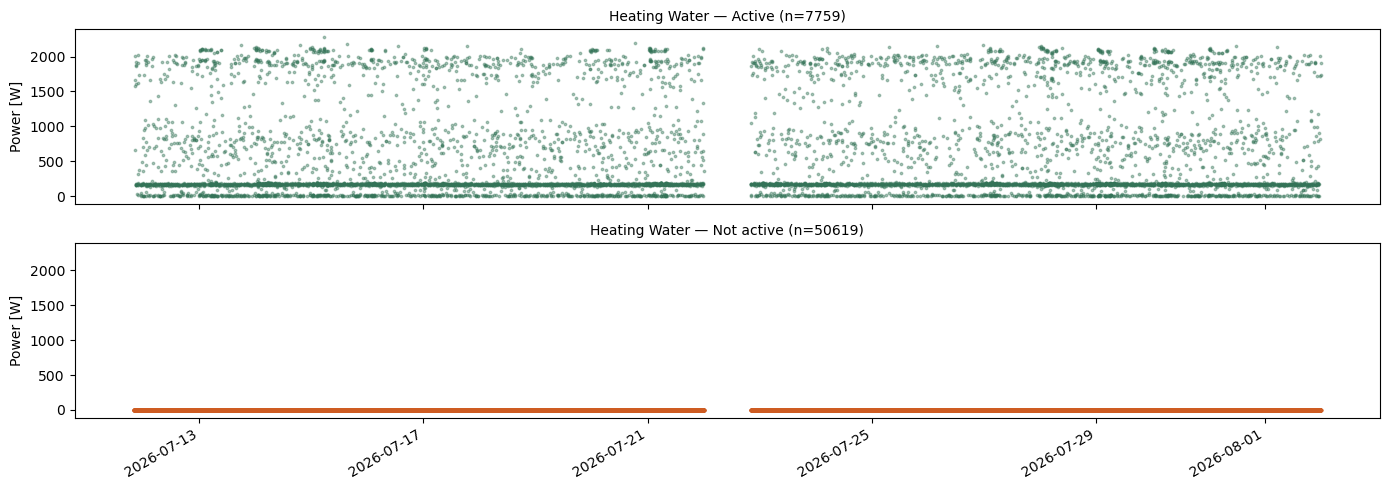

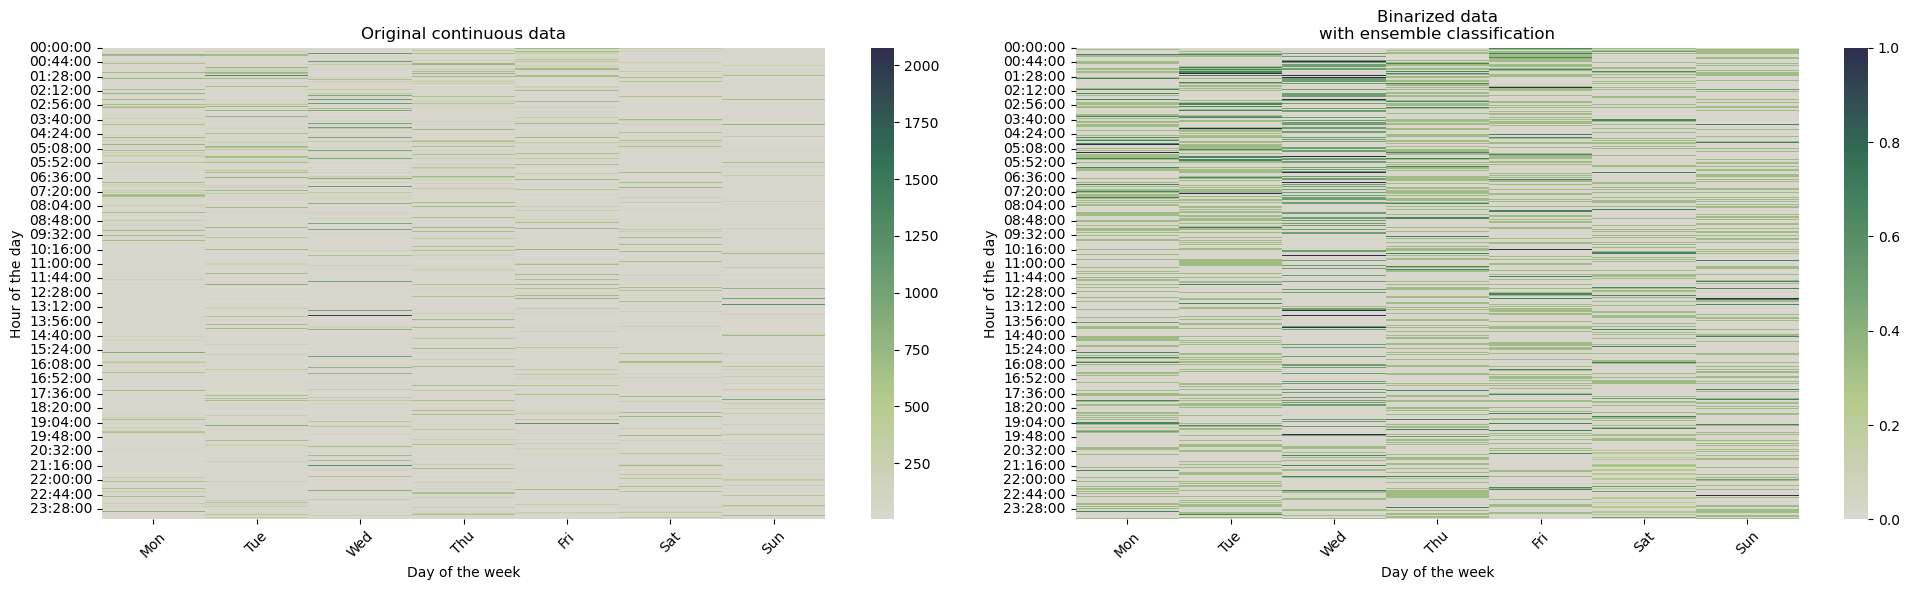

In [ ]:
pivot_raw, pivot_binary = plot_mode_detection_summary(
    long,
    power_col='power_w',
    label_col='final_ensemble',
    timestamp_col='timestamp',
    appliance_name='Heating Water',
)